# Test Neo4j Text2Cypher Workflow

This notebook tests the LangGraph workflow with a simple question to verify everything works correctly.

In [1]:
# Import dependencies
import sys
from pathlib import Path

# Add project root to Python path
project_root = Path.cwd().parent.parent
sys.path.insert(0, str(project_root))

from dotenv import load_dotenv
from neo4j_agent.agent import create_text2cypher_workflow
from neo4j_agent.utils.config import AppSettings

# Load environment variables from .env in project root
env_path = project_root / ".env"
load_dotenv(dotenv_path=env_path)

print("✅ Dependencies imported successfully!")
print(f"Project root: {project_root}")

✅ Dependencies imported successfully!
Project root: c:\Users\YancarloPerez\CustomerProjects\neo4j-text2cypher-agent\neo4j-text2cypher-agent


In [2]:
# Load configuration from honda config file
config_path = project_root / "app-config" / "honda" / "config.yml"
print(f"Loading config from: {config_path}")

settings = AppSettings.from_yaml(config_path)

print(f"\n📋 Configuration loaded:")
print(f"  - LLM Provider: {settings.llm.provider}")
print(f"  - LLM Model: {settings.llm.model}")
print(f"  - Neo4j Database: {settings.neo4j.database}")
print(f"  - UI Title: {settings.ui.title}")
print(f"  - Example Queries: {len(settings.cypher_examples)} loaded")
print("\n✅ Configuration loaded successfully!")

Loading config from: c:\Users\YancarloPerez\CustomerProjects\neo4j-text2cypher-agent\neo4j-text2cypher-agent\app-config\honda\config.yml

📋 Configuration loaded:
  - LLM Provider: openai
  - LLM Model: gpt-4o
  - Neo4j Database: honda
  - UI Title: IQS Data Explorer
  - Example Queries: 19 loaded

✅ Configuration loaded successfully!


In [3]:
# Create the Text2Cypher workflow
# This connects to Neo4j, loads schema, and builds the LangGraph workflow
print("🔧 Creating Text2Cypher workflow...")
app = create_text2cypher_workflow(settings)
print("✅ Workflow created successfully!")

🔧 Creating Text2Cypher workflow...
Loaded schema from cache: C:\Users\YancarloPerez\CustomerProjects\neo4j-text2cypher-agent\neo4j-text2cypher-agent\app-config\honda\neo4j_database_schema\honda_schema.json
✅ Workflow created successfully!


Workflow Graph Visualization

Generating workflow diagram with subgraph expansion (xray=True)...



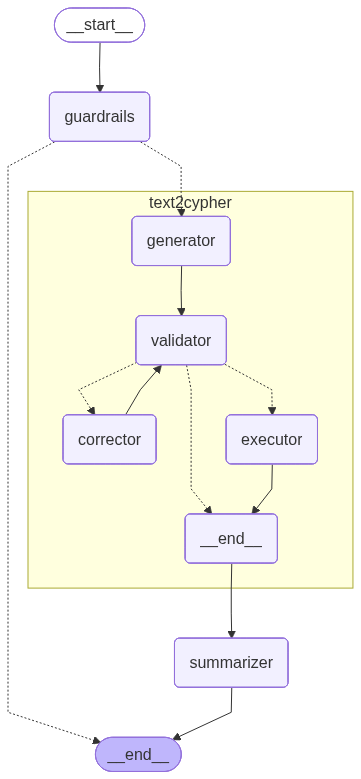


Graph visualization displayed above


In [4]:
# Visualize the workflow graph structure
from IPython.display import Image, display

print("Workflow Graph Visualization\n")

try:
    # Try to display the graph with xray=True to show subgraph internals
    print("Generating workflow diagram with subgraph expansion (xray=True)...\n")
    display(Image(app.get_graph(xray=True).draw_mermaid_png()))
    print("\nGraph visualization displayed above")
except Exception as e:
    # Fallback to ASCII if mermaid fails
    print(f"⚠️  Could not generate PNG diagram: {e}")
    print("\nFalling back to ASCII representation:\n")
    print(app.get_graph(xray=True).draw_ascii())
    print("\n✅ ASCII graph displayed above")

In [5]:
print("Testing workflow with a simple question...\n")

# Test question
question = "What are Honda Civic problems related to doors?"
print(f"Question: {question}\n")

# Create config with thread_id for conversation memory
config = {"configurable": {"thread_id": "test-session"}}

# Initial state
initial_state = {
    "question": question,
    "messages": []
}

# Run workflow
print("Running workflow...\n")
result = app.invoke(initial_state, config)

# Display results
print("=" * 80)
print("RESULTS")
print("=" * 80)

# Extract text2cypher output
text2cypher = result.get("text2cypher_output", {})

print(f"\nGenerated Cypher Query:")
cypher = text2cypher.get("cypher_query")
if cypher:
    print(cypher)
else:
    print("   No query generated")

print(f"\nQuery Results:")
query_results = text2cypher.get("query_results", [])
if query_results:
    print(f"   {len(query_results)} rows returned")
    # Show first few results
    for i, row in enumerate(query_results[:3], 1):
        print(f"   Row {i}: {row}")
    if len(query_results) > 3:
        print(f"   ... and {len(query_results) - 3} more rows")
else:
    print("   No results (answer generated from schema/knowledge)")

print(f"\nFinal Answer:")
print(result.get("final_answer", "No answer generated"))

print(f"\nContext Used:")
print(f"   - Similar examples: {result.get('num_examples_used', 0)}")
print(f"   - History items: {result.get('num_history_items', 0)}")

print(f"\n⚠️  Errors:")
print(result.get("error", "None"))

print("\n" + "=" * 80)
print("✅ Workflow test completed!")

Testing workflow with a simple question...

Question: What are Honda Civic problems related to doors?

Running workflow...

RESULTS

Generated Cypher Query:
MATCH (v:Verbatim {make: "Honda", model: "Civic"})-[:HAS_PROBLEM]->(p:Problem)
WHERE v.verbatimText CONTAINS 'door'
RETURN p.problem AS problem
LIMIT 50

Query Results:
   50 rows returned
   Row 1: {'problem': 'SEAT23: Seat materials scuff/soil easily'}
   Row 2: {'problem': 'SEAT97: Other Seat Problem(s)'}
   Row 3: {'problem': 'INT04: Door panels - Squeak/rattle/other noise'}
   ... and 47 more rows

Final Answer:
Honda Civic problems related to doors include:

- Doors - Hard to open/close
- Doors - Handle/latch/release - DTU
- Doors - Squeak/abnormal noise when opening/closing

Context Used:
   - Similar examples: 5
   - History items: 0

⚠️  Errors:
None

✅ Workflow test completed!
